In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Makes plots look cleaner
plt.style.use("ggplot")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("bank-additional-full.csv", sep=";")

In [3]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [4]:
print(df.shape)
print(df.columns)

(41188, 21)
Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [7]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [8]:
df["y"].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [9]:
categorical_columns = df.select_dtypes(include=["object"]).columns

for column in categorical_columns:
    print("\n" + "=" * 60)
    print("Column:", column)
    print("Unique values:", df[column].nunique())
    print(sorted(df[column].unique()))


Column: job
Unique values: 12
['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']

Column: marital
Unique values: 4
['divorced', 'married', 'single', 'unknown']

Column: education
Unique values: 8
['basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown']

Column: default
Unique values: 3
['no', 'unknown', 'yes']

Column: housing
Unique values: 3
['no', 'unknown', 'yes']

Column: loan
Unique values: 3
['no', 'unknown', 'yes']

Column: contact
Unique values: 2
['cellular', 'telephone']

Column: month
Unique values: 10
['apr', 'aug', 'dec', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']

Column: day_of_week
Unique values: 5
['fri', 'mon', 'thu', 'tue', 'wed']

Column: poutcome
Unique values: 3
['failure', 'nonexistent', 'success']

Column: y
Unique values: 2
['no', 'yes']


In [10]:
df["y"].value_counts(normalize=True) * 100

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

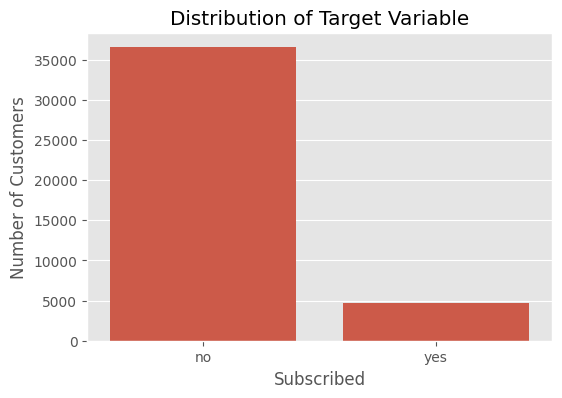

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="y")

plt.title("Distribution of Target Variable")
plt.xlabel("Subscribed")
plt.ylabel("Number of Customers")

plt.show()

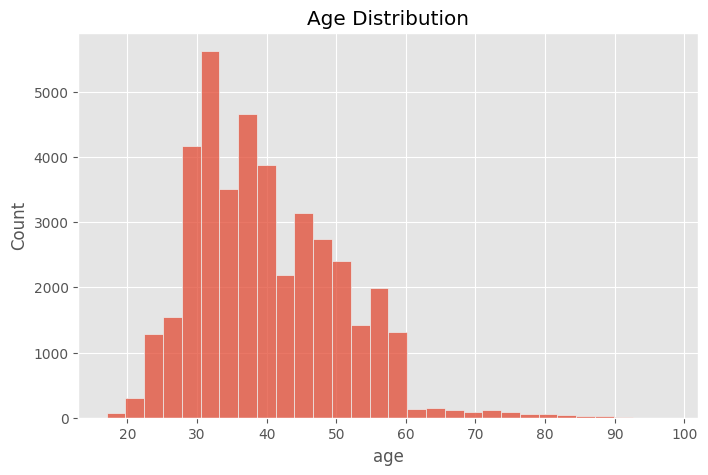

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=30)

plt.title("Age Distribution")

plt.show()

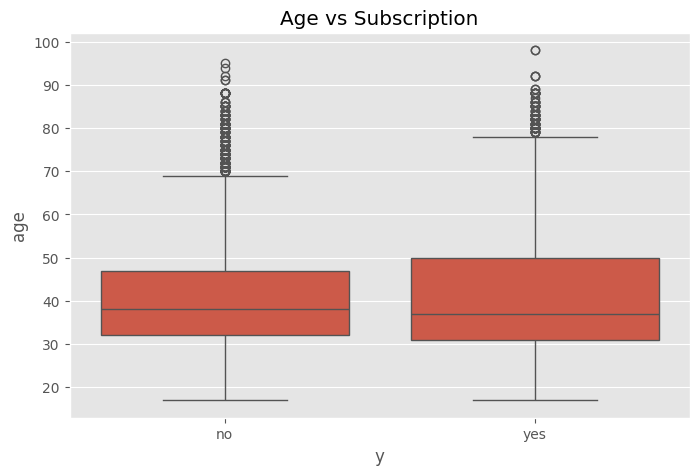

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="y", y="age")

plt.title("Age vs Subscription")

plt.show()

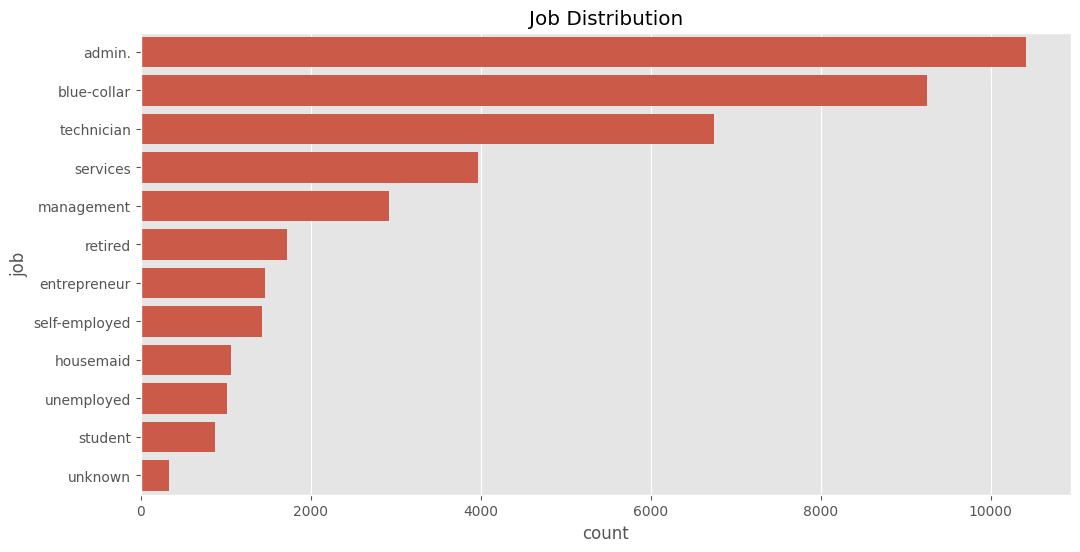

In [14]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="job",
    order=df["job"].value_counts().index
)

plt.title("Job Distribution")

plt.show()

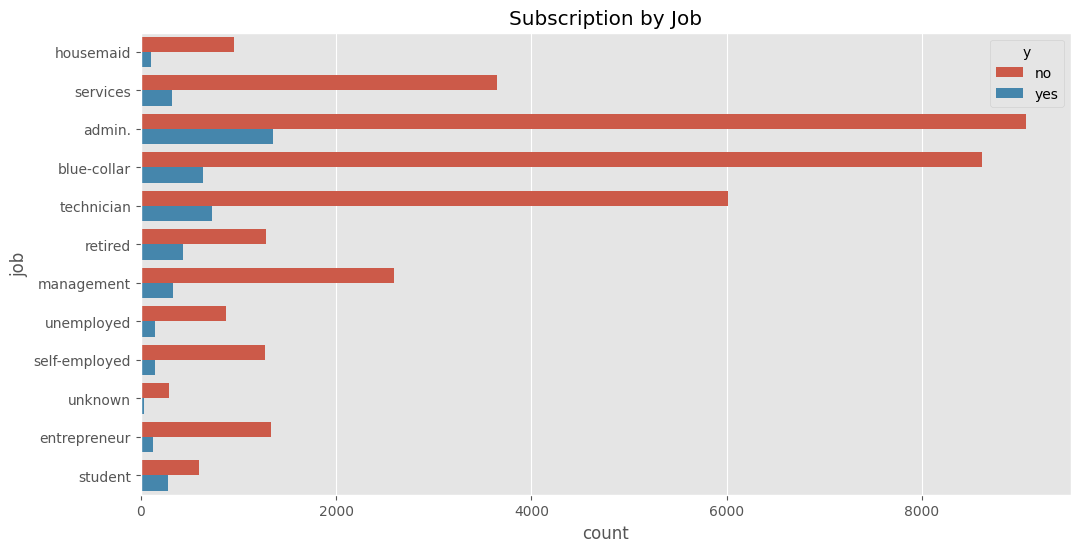

In [15]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="job",
    hue="y"
)

plt.title("Subscription by Job")

plt.show()

In [16]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

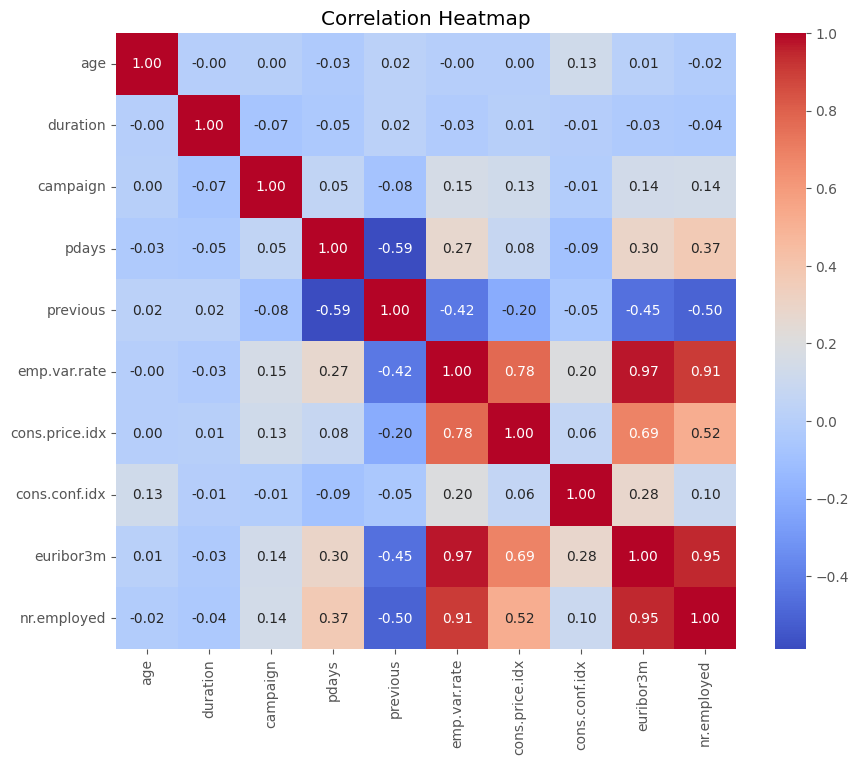

In [17]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

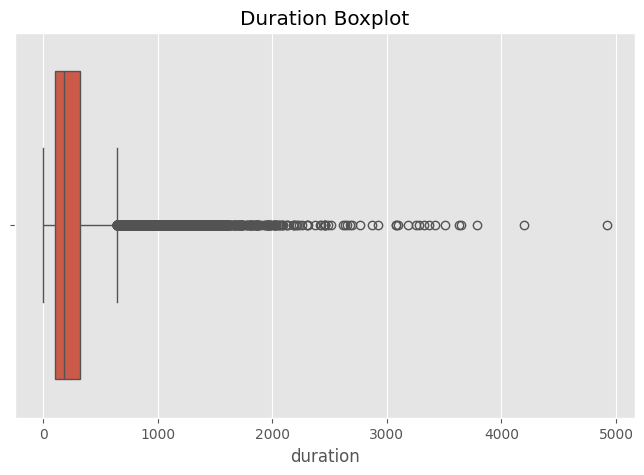

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["duration"])

plt.title("Duration Boxplot")

plt.show()

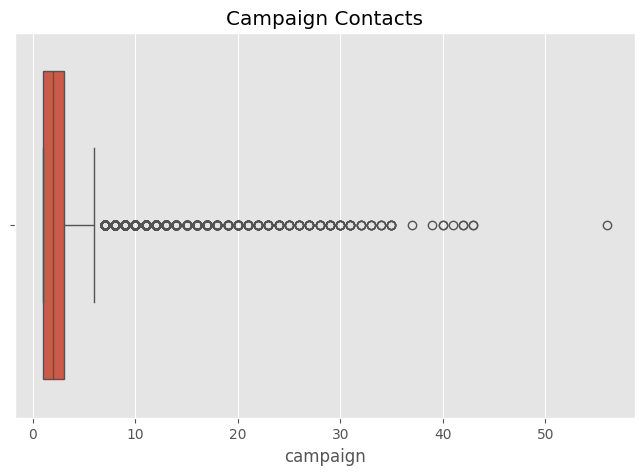

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["campaign"])

plt.title("Campaign Contacts")

plt.show()

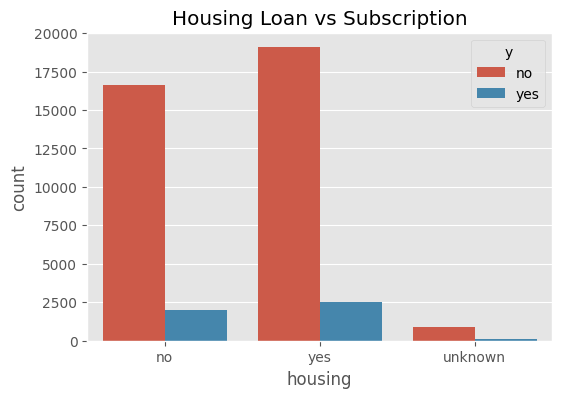

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="housing",
    hue="y"
)

plt.title("Housing Loan vs Subscription")

plt.show()

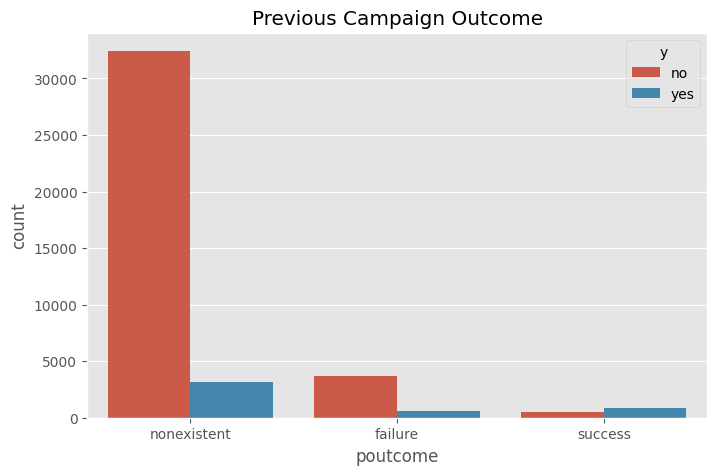

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="poutcome",
    hue="y"
)

plt.title("Previous Campaign Outcome")

plt.show()

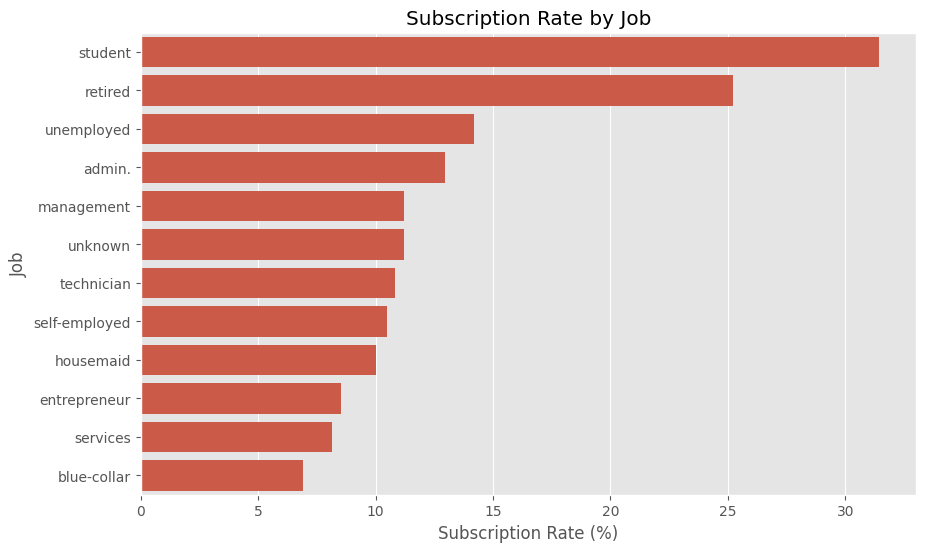

In [22]:
subscription_rate = (
    df.groupby("job")["y"]
      .value_counts(normalize=True)
      .rename("rate")
      .mul(100)
      .reset_index()
)

subscription_rate = subscription_rate[
    subscription_rate["y"] == "yes"
]

subscription_rate = subscription_rate.sort_values(
    by="rate",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=subscription_rate,
    x="rate",
    y="job"
)

plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")

plt.title("Subscription Rate by Job")

plt.show()

****Exploratory Data Analysis Summary****
1. The dataset contains 41,188 customer records and 21 columns (20 features and 1 target).
2. There are no missing (NaN) values, although some categorical features contain "unknown" as a valid category.
3. The target variable (y) is imbalanced, with approximately 88.7% "No" and 11.3% "Yes".
4. The dataset contains both numerical and categorical features, so encoding will be required before model training.
5. A few numerical features, such as duration and campaign, contain high values that may represent outliers.
6. The visualizations helped us understand customer demographics, campaign characteristics, and relationships between variables.

In [23]:
# Features (inputs)
X = df.drop("y", axis=1)

# Target (output)
y = df["y"]

In [24]:
print(X.head())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  duration  campaign  pdays  previous     poutcome  \
0   may         mon       261         1    999         0  nonexistent   
1   may         mon       149         1    999         0  nonexistent   
2   may         mon       226         1    999         0  nonexistent   
3   may         mon       151         1    999         0  nonexistent   
4   may         mon       307         1    999         0  nonexistent   

   emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed  
0           1.1          93.994

In [25]:
print(y.head())

0    no
1    no
2    no
3    no
4    no
Name: y, dtype: object


In [26]:
y = y.map({
    "no": 0,
    "yes": 1
})

In [27]:
print(y.value_counts())

y
0    36548
1     4640
Name: count, dtype: int64


In [28]:
X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

In [29]:
X.columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'marital_unknown',
       'education_basic.6y', 'education_basic.9y', 'education_high.school',
       'education_illiterate', 'education_professional.course',
       'education_university.degree', 'education_unknown', 'default_unknown',
       'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown',
       'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue',
       'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_s

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [31]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(32950, 53)
(8238, 53)
(32950,)
(8238,)


In [32]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

y
0    0.887344
1    0.112656
Name: proportion, dtype: float64
y
0    0.887351
1    0.112649
Name: proportion, dtype: float64


In [33]:
scaler = StandardScaler()

In [34]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

In [36]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

knn = KNeighborsClassifier(
    n_neighbors=5
)

naive_bayes = GaussianNB()

random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

In [37]:
logistic_model.fit(X_train, y_train)

decision_tree.fit(X_train, y_train)

knn.fit(X_train, y_train)

naive_bayes.fit(X_train, y_train)

random_forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix
)

def evaluate_model(model_name, model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)
    mcc = matthews_corrcoef(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)

    print("\n" + "=" * 60)
    print(f"Model: {model_name}")
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")
    print(f"MCC      : {mcc:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "MCC": mcc
    }

In [39]:
logistic_results = evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_test,
    y_test
)

tree_results = evaluate_model(
    "Decision Tree",
    decision_tree,
    X_test,
    y_test
)

knn_results = evaluate_model(
    "KNN",
    knn,
    X_test,
    y_test
)

nb_results = evaluate_model(
    "Naive Bayes",
    naive_bayes,
    X_test,
    y_test
)

rf_results = evaluate_model(
    "Random Forest",
    random_forest,
    X_test,
    y_test
)


Model: Logistic Regression
Accuracy : 0.9164
Precision: 0.7100
Recall   : 0.4353
F1 Score : 0.5397
AUC      : 0.9424
MCC      : 0.5147

Confusion Matrix:
[[7145  165]
 [ 524  404]]

Model: Decision Tree
Accuracy : 0.9185
Precision: 0.6777
Recall   : 0.5280
F1 Score : 0.5936
AUC      : 0.9328
MCC      : 0.5544

Confusion Matrix:
[[7077  233]
 [ 438  490]]

Model: KNN
Accuracy : 0.9022
Precision: 0.6178
Recall   : 0.3448
F1 Score : 0.4426
AUC      : 0.8322
MCC      : 0.4138

Confusion Matrix:
[[7112  198]
 [ 608  320]]

Model: Naive Bayes
Accuracy : 0.7527
Precision: 0.2902
Recall   : 0.8265
F1 Score : 0.4296
AUC      : 0.8493
MCC      : 0.3860

Confusion Matrix:
[[5434 1876]
 [ 161  767]]

Model: Random Forest
Accuracy : 0.9133
Precision: 0.7758
Recall   : 0.3244
F1 Score : 0.4574
AUC      : 0.9463
MCC      : 0.4663

Confusion Matrix:
[[7223   87]
 [ 627  301]]


In [40]:
results_df = pd.DataFrame([
    logistic_results,
    tree_results,
    knn_results,
    nb_results,
    rf_results
])

results_df

,Model,Accuracy,Precision,Recall,F1,AUC,MCC
0,Logistic Regression,0.916363,0.710018,0.435345,0.539746,0.942420,0.514658
1,Decision Tree,0.918548,0.677732,0.528017,0.593580,0.932771,0.554378
2,KNN,0.902161,0.617761,0.344828,0.442600,0.832203,0.413840
3,Naive Bayes,0.752731,0.290201,0.826509,0.429572,0.849332,0.385978
4,Random Forest,0.913328,0.775773,0.324353,0.457447,0.946320,0.466300
